<a href="https://colab.research.google.com/github/Nisarga25/ML_2_063/blob/main/findS(063).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIND-S ALGORITHM
CAR BUYING DATASET


STEP-BY-STEP HYPOTHESIS
h0 : {'Age': '0', 'Income': '0', 'Credit': '0', 'Employment': '0'}
h1 : {'Age': 'Young', 'Income': 'High', 'Credit': 'Good', 'Employment': 'Stable'}
h2 : {'Age': 'Young', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}
Ex3 (neg) : {'Age': 'Young', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}
h4 : {'Age': 'Young', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}
h5 : {'Age': '?', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}
Ex6 (neg) : {'Age': '?', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}

FINAL HYPOTHESIS
{'Age': '?', 'Income': 'High', 'Credit': 'Good', 'Employment': '?'}


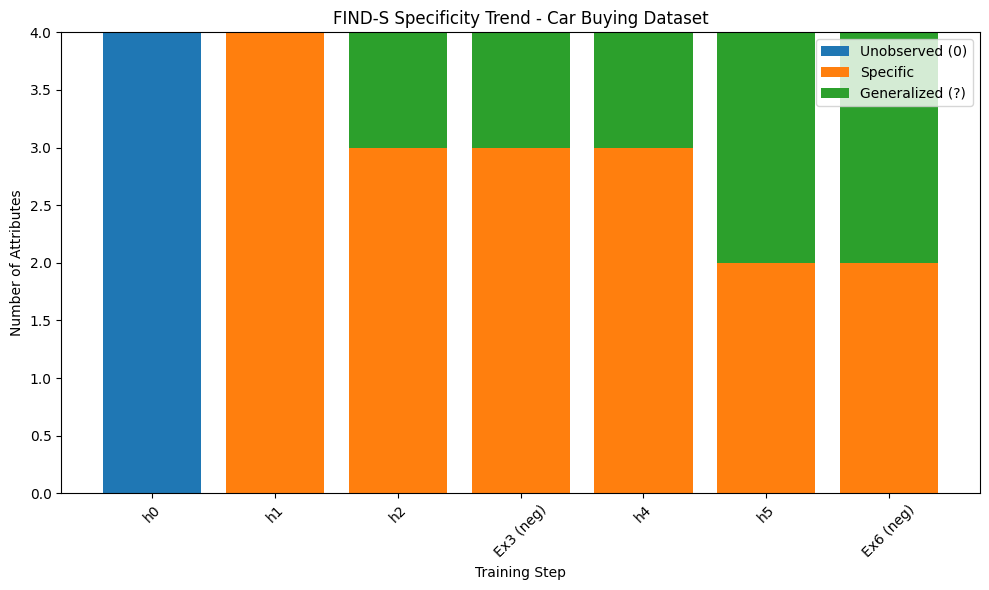

Saved: car_buying_specificity_trend.png


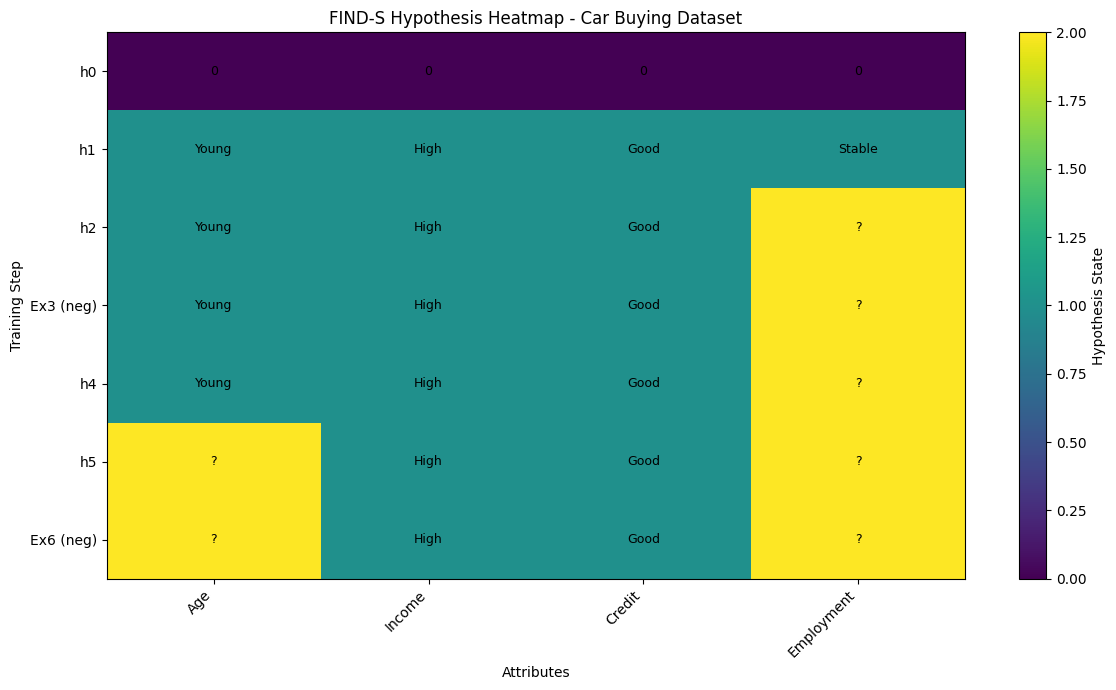

Saved: car_buying_hypothesis_heatmap.png


In [1]:
"""
FIND-S Algorithm with a Different Dataset
==========================================

Dataset: Car Buying Dataset

FIND-S learns the maximally specific hypothesis
consistent with all positive training examples.

Hypothesis notation:
    '0' -> no value observed yet
    '?' -> any value is acceptable
    value -> specific value is required
"""

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. FIND-S ALGORITHM
# ============================================================

def find_s(training_data, target_col="BuyCar", positive_label="Yes"):

    # Get attributes except target column
    attributes = [
        attr for attr in training_data[0].keys()
        if attr != target_col
    ]

    # Initialize most specific hypothesis
    hypothesis = {
        attr: "0"
        for attr in attributes
    }

    print("Initial Hypothesis:")
    print("h0 =", hypothesis)
    print()

    # Process every training example
    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # Ignore negative examples
        if label != positive_label:

            print(
                f"Example {i} ({label}): "
                "Negative -> Ignored"
            )

            continue

        # Process positive example
        for attr in attributes:

            if hypothesis[attr] == "0":

                # First positive example
                hypothesis[attr] = example[attr]

            elif hypothesis[attr] != example[attr]:

                # Generalize if values are different
                hypothesis[attr] = "?"

        print(
            f"Example {i} ({label}): "
            f"Positive -> h{i} = {hypothesis}"
        )

    print()
    print("Final Hypothesis:")
    print(hypothesis)

    return hypothesis


# ============================================================
# 2. FIND-S WITH HISTORY
# ============================================================

def find_s_with_history(
    training_data,
    target_col="BuyCar",
    positive_label="Yes"
):

    attributes = [
        attr for attr in training_data[0].keys()
        if attr != target_col
    ]

    # Initial hypothesis
    hypothesis = {
        attr: "0"
        for attr in attributes
    }

    # Store history
    history = [
        ("h0", dict(hypothesis), None)
    ]

    # Process examples
    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # Negative example
        if label != positive_label:

            history.append(
                (
                    f"Ex{i}\n(neg)",
                    dict(hypothesis),
                    False
                )
            )

            continue

        # Positive example
        for attr in attributes:

            if hypothesis[attr] == "0":

                hypothesis[attr] = example[attr]

            elif hypothesis[attr] != example[attr]:

                hypothesis[attr] = "?"

        history.append(
            (
                f"h{i}",
                dict(hypothesis),
                True
            )
        )

    return hypothesis, history, attributes


# ============================================================
# 3. SPECIFICITY TREND
# ============================================================

def plot_specificity_trend(history, attributes):

    steps = []
    unobserved = []
    specific = []
    generalized = []

    for label, hypothesis, _ in history:

        steps.append(label.replace("\n", " "))

        count_zero = 0
        count_specific = 0
        count_general = 0

        for attr in attributes:

            value = hypothesis[attr]

            if value == "0":

                count_zero += 1

            elif value == "?":

                count_general += 1

            else:

                count_specific += 1

        unobserved.append(count_zero)
        specific.append(count_specific)
        generalized.append(count_general)

    x = np.arange(len(steps))

    plt.figure(figsize=(10, 6))

    plt.bar(
        x,
        unobserved,
        label="Unobserved (0)"
    )

    plt.bar(
        x,
        specific,
        bottom=unobserved,
        label="Specific"
    )

    bottom_values = [
        unobserved[i] + specific[i]
        for i in range(len(steps))
    ]

    plt.bar(
        x,
        generalized,
        bottom=bottom_values,
        label="Generalized (?)"
    )

    plt.xticks(
        x,
        steps,
        rotation=45
    )

    plt.xlabel("Training Step")
    plt.ylabel("Number of Attributes")

    plt.title(
        "FIND-S Specificity Trend - Car Buying Dataset"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        "car_buying_specificity_trend.png",
        dpi=150
    )

    plt.show()

    print(
        "Saved: car_buying_specificity_trend.png"
    )


# ============================================================
# 4. HYPOTHESIS HEATMAP
# ============================================================

def plot_hypothesis_heatmap(history, attributes):

    matrix = []

    for _, hypothesis, _ in history:

        row = []

        for attr in attributes:

            value = hypothesis[attr]

            if value == "0":

                row.append(0)

            elif value == "?":

                row.append(2)

            else:

                row.append(1)

        matrix.append(row)

    matrix = np.array(matrix)

    labels = [
        label.replace("\n", " ")
        for label, _, _ in history
    ]

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(
        matrix,
        aspect="auto"
    )

    plt.colorbar(
        label="Hypothesis State"
    )

    plt.xticks(
        range(len(attributes)),
        attributes,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(labels)),
        labels
    )

    # Write actual hypothesis values
    for i, (_, hypothesis, _) in enumerate(history):

        for j, attr in enumerate(attributes):

            plt.text(
                j,
                i,
                hypothesis[attr],
                ha="center",
                va="center",
                fontsize=9
            )

    plt.xlabel("Attributes")
    plt.ylabel("Training Step")

    plt.title(
        "FIND-S Hypothesis Heatmap - Car Buying Dataset"
    )

    plt.tight_layout()

    plt.savefig(
        "car_buying_hypothesis_heatmap.png",
        dpi=150
    )

    plt.show()

    print(
        "Saved: car_buying_hypothesis_heatmap.png"
    )


# ============================================================
# 5. DIFFERENT DATASET
# ============================================================

training_data = [

    {
        "Age": "Young",
        "Income": "High",
        "Credit": "Good",
        "Employment": "Stable",
        "BuyCar": "Yes"
    },

    {
        "Age": "Young",
        "Income": "High",
        "Credit": "Good",
        "Employment": "Unstable",
        "BuyCar": "Yes"
    },

    {
        "Age": "Middle",
        "Income": "Low",
        "Credit": "Bad",
        "Employment": "Unstable",
        "BuyCar": "No"
    },

    {
        "Age": "Young",
        "Income": "High",
        "Credit": "Good",
        "Employment": "Stable",
        "BuyCar": "Yes"
    },

    {
        "Age": "Middle",
        "Income": "High",
        "Credit": "Good",
        "Employment": "Stable",
        "BuyCar": "Yes"
    },

    {
        "Age": "Old",
        "Income": "Low",
        "Credit": "Bad",
        "Employment": "Unstable",
        "BuyCar": "No"
    }

]


# ============================================================
# 6. RUN FIND-S
# ============================================================

print("=" * 60)
print("FIND-S ALGORITHM")
print("CAR BUYING DATASET")
print("=" * 60)
print()

final_hypothesis, history, attributes = find_s_with_history(
    training_data,
    target_col="BuyCar",
    positive_label="Yes"
)


# ============================================================
# 7. DISPLAY STEP-BY-STEP HYPOTHESIS
# ============================================================

print()
print("=" * 60)
print("STEP-BY-STEP HYPOTHESIS")
print("=" * 60)

for label, hypothesis, _ in history:

    print(
        f"{label.replace(chr(10), ' ')} : "
        f"{hypothesis}"
    )


# ============================================================
# 8. FINAL HYPOTHESIS
# ============================================================

print()
print("=" * 60)
print("FINAL HYPOTHESIS")
print("=" * 60)

print(final_hypothesis)


# ============================================================
# 9. GENERATE GRAPHS
# ============================================================

plot_specificity_trend(
    history,
    attributes
)

plot_hypothesis_heatmap(
    history,
    attributes
)